In [2]:
%env XLA_FLAGS="--xla_gpu_cuda_data_dir=/opt/modules/i12g/anaconda/envs/ml4rg-salukilike/lib/python3.10/site-packages/nvidia/cuda_nvcc"

env: XLA_FLAGS="--xla_gpu_cuda_data_dir=/opt/modules/i12g/anaconda/envs/ml4rg-salukilike/lib/python3.10/site-packages/nvidia/cuda_nvcc"


In [3]:
import os
print(os.environ.get("XLA_FLAGS"))

"--xla_gpu_cuda_data_dir=/opt/modules/i12g/anaconda/envs/ml4rg-salukilike/lib/python3.10/site-packages/nvidia/cuda_nvcc"


In [4]:
# i had issues with gpu, so for now set to cpu mode

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [5]:
from __future__ import print_function
from optparse import OptionParser
import json
import os
import pdb
import sys
import time

import h5py
import joblib
import numpy as np
import pandas as pd
from scipy.stats import poisson
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
import tensorflow as tf

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns

from basenji import plots
from basenji import trainer
from basenji import dataset
from basenji import rnann
%matplotlib inline
if tf.__version__[0] == '1':
  tf.compat.v1.enable_eager_execution()

2026-06-16 14:51:18.207846: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-16 14:51:20.664335: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [6]:
base_path = '/s/project/ml4rg_students/2026/project03'
fold = f'{base_path}/datasets/deeplearning/train_gru/f0_c0'

In [94]:
fold

'/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0'

In [109]:
head_i = 0
shifts = [0]
split_label = 'valid'

params_file = f"{fold}/train/params.json"
model_file = f"{fold}/train/model0_best.h5"
data_dir = f"{fold}/data0"
targets_file = f"{data_dir}/targets.txt"

In [110]:
with open(params_file) as params_open:
    params = json.load(params_open)
params_model = params['model']
params_train = params['train']

eval_data = dataset.RnaDataset(data_dir,
    split_label=split_label,
    batch_size=params_train['batch_size'],
    mode='eval'
)
print('done')
seqnn_model = rnann.RnaNN(params_model)
print('done')
seqnn_model.restore(model_file, head_i)
print('done')
seqnn_model.build_ensemble(shifts)
print('done')

targets_df = pd.read_csv(targets_file, index_col=0, sep='\t')

done
Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequence (InputLayer)       [(None, 12288, 6)]        0         
                                                                 
 stochastic_shift_3 (Stocha  (None, 12288, 6)          0         
 sticShift)                                                      
                                                                 
 conv1d_21 (Conv1D)          (None, 12284, 64)         1920      
                                                                 
 layer_normalization_21 (La  (None, 12284, 64)         128       
 yerNormalization)                                               
                                                                 
 re_lu_27 (ReLU)             (None, 12284, 64)         0         
                                                                 
 conv1d_22 (Conv1D)          (None, 12280, 64)        

In [98]:
# default from saluki_test.py

test_loss, test_metric1, test_metric2 = seqnn_model.evaluate(eval_data)

# print summary statistics
print('\nTest Loss:         %7.5f' % test_loss)
print('Test PearsonR:     %7.5f' % test_metric1.mean())
print('Test R2:           %7.5f' % test_metric2.mean())

21/21 [==============================] - 7s 312ms/step - loss: 0.6566 - pearsonr: 0.7767 - r2: 0.4738

Test Loss:         0.65662
Test PearsonR:     0.77670
Test R2:           0.47383


## Held out eval

In [111]:
df_genes = pd.read_table('/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data0/genes.tsv')

In [112]:
df_genes['Split'].value_counts()

Split
train    10377
test      1297
valid     1294
Name: count, dtype: int64

In [113]:
y_pred = seqnn_model.predict(eval_data)

21/21 [==============================] - 7s 311ms/step


In [114]:
y_pred.shape

(1294, 1)

In [122]:
eval_data.mode

'eval'

In [129]:
y_test = eval_data.numpy()[1]

In [130]:
y_test.shape

(1294, 1, 1)

In [131]:
y_test = y_test.squeeze()
y_pred = y_pred.squeeze()

In [132]:
from scipy.stats import pearsonr

In [133]:
def pearson(x, y):
    r = pearsonr(x, y)[0]
    return round(r, 4)

In [134]:
pearson(y_test, y_pred)

0.7767

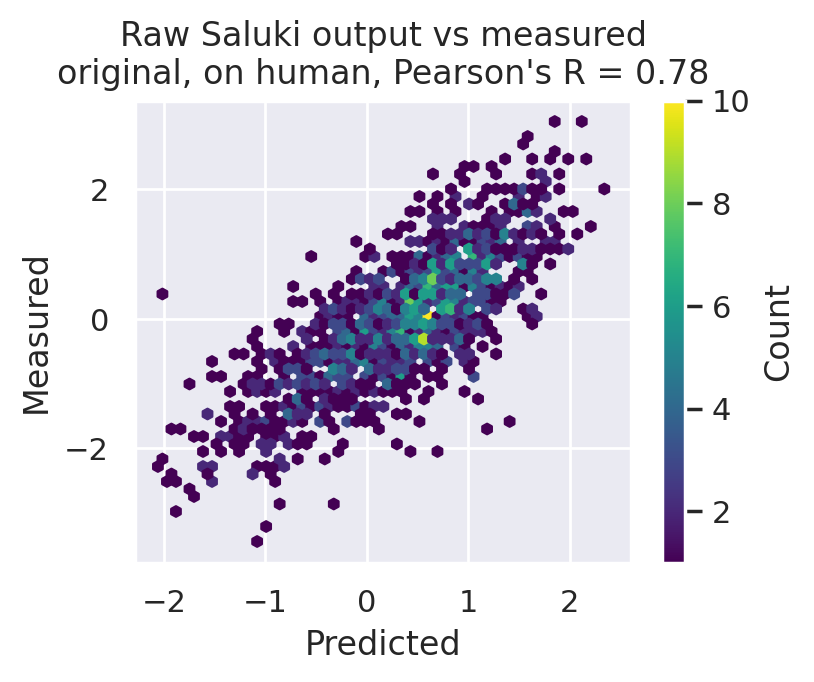

In [135]:
sns.set_theme()

plt.figure(figsize=(4, 3), dpi=200)

hb = plt.hexbin(
    y_pred,
    y_test,
    gridsize=50,
    mincnt=1,
    cmap="viridis"
)

plt.colorbar(hb, label="Count")
plt.xlabel("Predicted")
plt.ylabel("Measured")
plt.title(f"Raw Saluki output vs measured\noriginal, on human, Pearson's R = {pearson(y_test, y_pred):.2f}")
plt.show()

In [124]:
df_val_genes = df_genes[df_genes['Split'] == 'valid'].copy()

In [125]:
df_val_genes['orig_saluki_pred'] = y_pred

In [128]:
pearson(df_val_genes['Stability'], df_val_genes['orig_saluki_pred'])

0.7767

In [140]:
df_val_genes.to_csv('/s/project/ml4rg_students/2026/project03/project-half-life/results/val_genes.csv', index=False)

In [1]:
# import sys
# !{sys.executable} -m pip install pyranges --quiet

# !{sys.executable} -m pip install scikit-learn --quiet

In [2]:
import os
import pandas as pd
import numpy as np
import pyranges as pr
from tqdm import tqdm
tqdm.pandas()

In [26]:
df_vars = pd.read_parquet("/s/project/ml4rg_students/2026/project03/datasets/human/GTEx_eQTLs/GTEx_Analysis_v11_eQTL_SuSiE/Brain_Cortex.v11.eQTLs.SuSiE_summary.parquet")

In [27]:
df_vars = df_vars.rename(
    columns={
        'phenotype_id': 'gene_id',
        'pip': 'PIP'
    }
)

In [28]:
df_vars['gene_id'] = df_vars['gene_id'].progress_apply(lambda x: x.split('.')[0])

100%|██████████| 268624/268624 [00:00<00:00, 1578789.81it/s]


In [5]:
df_genes = pd.read_table('/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data0/genes.tsv')

In [6]:
df_genes

,Unnamed: 0,Fold,Gene,Stability,Length,Split
0,0,0,ENSG00000000457,-1.437941,3090,test
1,1,0,ENSG00000001631,-0.184992,4762,test
2,2,0,ENSG00000002549,1.395107,2213,test
3,3,0,ENSG00000003137,-0.657063,4732,test
4,4,0,ENSG00000003987,0.064368,3850,test
...,...,...,...,...,...,...
12963,12963,9,ENSG00000273045,-0.975974,1667,train
12964,12964,9,ENSG00000274286,-0.480628,3371,train
12965,12965,9,ENSG00000275004,-1.830486,5721,train
12966,12966,9,ENSG00000275183,-1.360496,1916,train


In [7]:
gtf = pr.read_gtf("/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/datasets/human/Homo_sapiens.GRCh38.83.gtf.gz")#.as_df()

In [8]:
gtf.columns

Index(['Chromosome', 'Source', 'Feature', 'Start', 'End', 'Score', 'Strand',
       'Frame', 'gene_id', 'gene_version', 'gene_name', 'gene_source',
       'gene_biotype', 'havana_gene', 'havana_gene_version', 'transcript_id',
       'transcript_version', 'transcript_name', 'transcript_source',
       'transcript_biotype', 'havana_transcript', 'havana_transcript_version',
       'tag', 'transcript_support_level', 'exon_number', 'exon_id',
       'exon_version', 'ccds_id', 'protein_id', 'protein_version'],
      dtype='str')

In [10]:
df_expr = pd.read_parquet("/s/project/QNA/gtex_counts/GTEx_median_raw_counts_per_tissue.parquet")

In [11]:
df_expr['gene_id'] = df_expr['gene_id'].progress_apply(lambda x: x.split('.')[0])

100%|██████████| 56200/56200 [00:00<00:00, 1574036.83it/s]


In [12]:
df_expr = df_expr.set_index('gene_id')

In [13]:
df_expr = df_expr.drop(columns='gene_name')

In [38]:
len(var_gr)

0

In [36]:
df

""


In [34]:
var_gr_safe = var_gr.copy()

In [43]:
var_gr_safe

,gene_id,gene_name,biotype,variant_id,PIP,af,cs_id,cs_size,afc,afc_se,gene_biotype,Chromosome,Start,Ref,Alt,End
0,ENSG00000188976,NOC2L,protein_coding,chr1_817889_C_G_b38,0.111075,0.994403,1,9,0.326469,0.362557,protein_coding,chr1,817889,C,G,817890
1,ENSG00000188976,NOC2L,protein_coding,chr1_832400_G_A_b38,0.111075,0.994403,1,9,NaN,NaN,protein_coding,chr1,832400,G,A,832401
2,ENSG00000188976,NOC2L,protein_coding,chr1_834695_C_T_b38,0.111075,0.994403,1,9,NaN,NaN,protein_coding,chr1,834695,C,T,834696
3,ENSG00000188976,NOC2L,protein_coding,chr1_843189_A_G_b38,0.111075,0.994403,1,9,NaN,NaN,protein_coding,chr1,843189,A,G,843190
4,ENSG00000188976,NOC2L,protein_coding,chr1_844647_G_T_b38,0.111075,0.994403,1,9,NaN,NaN,protein_coding,chr1,844647,G,T,844648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164558,ENSG00000155961,RAB39B,protein_coding,chrX_155695384_C_T_b38,0.001846,0.276119,1,212,NaN,NaN,protein_coding,chrX,155695384,C,T,155695385
164559,ENSG00000155961,RAB39B,protein_coding,chrX_155699751_C_T_b38,0.005713,0.274254,1,212,NaN,NaN,protein_coding,chrX,155699751,C,T,155699752
164560,ENSG00000155961,RAB39B,protein_coding,chrX_155700291_CAA_C_b38,0.005713,0.274254,1,212,NaN,NaN,protein_coding,chrX,155700291,CAA,C,155700292
164561,ENSG00000155961,RAB39B,protein_coding,chrX_155708407_T_C_b38,0.002748,0.186567,1,212,NaN,NaN,protein_coding,chrX,155708407,T,C,155708408


In [44]:
cds

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,havana_transcript,havana_transcript_version,tag,transcript_support_level,exon_number,exon_id,exon_version,ccds_id,protein_id,protein_version
0,1,ensembl_havana,CDS,69090,70005,.,+,0,ENSG00000186092,4,...,OTTHUMT00000003223,2,basic,NA,1,NaN,NaN,CCDS30547,ENSP00000334393,3
1,1,ensembl,CDS,182708,182746,.,+,0,ENSG00000279928,1,...,NaN,NaN,basic,1,1,NaN,NaN,NaN,ENSP00000485457,1
2,1,ensembl,CDS,183113,183240,.,+,1,ENSG00000279928,1,...,NaN,NaN,basic,1,2,NaN,NaN,NaN,ENSP00000485457,1
3,1,ensembl,CDS,183921,184155,.,+,0,ENSG00000279928,1,...,NaN,NaN,basic,1,3,NaN,NaN,NaN,ENSP00000485457,1
4,1,havana,CDS,925941,926013,.,+,0,ENSG00000187634,10,...,OTTHUMT00000316521,2,mRNA_end_NF,3,2,NaN,NaN,NaN,ENSP00000411579,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702405,Y,ensembl,CDS,25043945,25044023,.,-,0,ENSG00000185894,8,...,NaN,NaN,basic,2,1,NaN,NaN,CCDS44030,ENSP00000480751,1
702406,Y,ensembl,CDS,25041768,25041886,.,-,0,ENSG00000185894,8,...,NaN,NaN,basic,2,2,NaN,NaN,CCDS44030,ENSP00000480751,1
702407,Y,ensembl,CDS,25038808,25038914,.,-,2,ENSG00000185894,8,...,NaN,NaN,basic,2,3,NaN,NaN,CCDS44030,ENSP00000480751,1
702408,Y,ensembl,CDS,25038100,25038116,.,-,1,ENSG00000185894,8,...,NaN,NaN,basic,2,4,NaN,NaN,CCDS44030,ENSP00000480751,1


## Compare values

In [59]:
df_1 = pd.read_table('/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data0/genes.tsv')
df_2 = pd.read_table('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/toga_13_species_updated/saluki_human.hg38.hg38.tsv')

# df_1 = pd.read_table('/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data1/genes.tsv')
# df_2 = pd.read_table('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/toga_13_species_updated/saluki_mouse.mm10.mm10.tsv')

In [49]:
df_1.columns

Index(['Unnamed: 0', 'Fold', 'Gene', 'Stability', 'Length', 'Split'], dtype='object')

In [50]:
df_2 = df_2.rename(columns={'gene': 'Gene'})

In [51]:
df_j = df_1.set_index('Gene').join(
    df_2.set_index('Gene'), how='inner'
).reset_index()

In [52]:
df_val = df_j[df_j['Split'] == 'valid']

In [53]:
df_val.columns

Index(['Gene', 'Unnamed: 0', 'Fold', 'Stability', 'Length', 'Split', 'chrom',
       'start', 'end', 'strand', 'fold', 'start_cds', 'end_cds', 'block_count',
       'block_sizes', 'block_starts', 'block_count_cds', 'block_sizes_cds',
       'block_starts_cds', 'half_life', 'seq', 'frame', 'splice'],
      dtype='object')

In [54]:
np.sum(df_j['Fold'] != df_j['fold'])

0

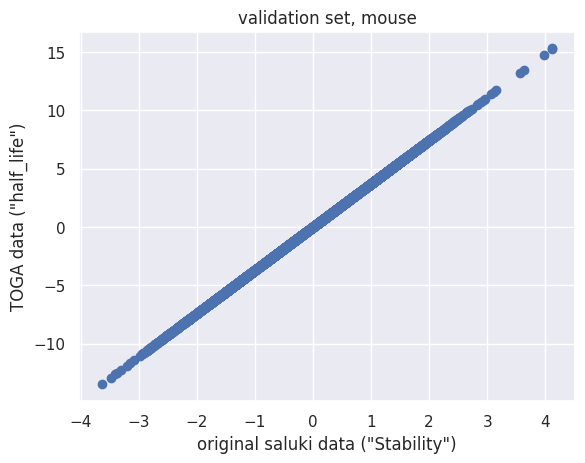

In [55]:
plt.scatter(df_j['Stability'], df_j['half_life'])
plt.xlabel('original saluki data ("Stability")')
plt.ylabel('TOGA data ("half_life")')
plt.title('validation set, mouse')
plt.show()

In [101]:
df_1 = pd.read_table('/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data0/genes.tsv')
df_2 = pd.read_table('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/toga_13_species_updated/saluki_human.hg38.hg38.tsv')

# df_1 = pd.read_table('/s/project/ml4rg_students/2026/project03/datasets/deeplearning/train_gru/f0_c0/data1/genes.tsv')
# df_2 = pd.read_table('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/toga_13_species_updated/saluki_mouse.mm10.mm10.tsv')

In [102]:
df_2 = df_2.rename(columns={'gene': 'Gene'})

In [103]:
df_j = df_2.set_index('Gene').join(
    df_1.set_index('Gene')['Stability'], how='left'
).reset_index()

In [104]:
df_j = df_j.rename(columns={
    'half_life': 'toga_half_life',
    'Stability': 'half_life'
})

In [105]:
assert df_j[df_j['half_life'].isna()].shape[0] == 0

In [80]:
df_j.to_csv("/s/project/ml4rg_students/2026/project03/project-half-life/saluki_orig_inputs/mouse.tsv", sep='\t', index=None)

In [106]:
df_1_subset = (
    df_1.set_index("Gene")
       .loc[df_2["Gene"]]
       .reset_index()
)

In [107]:
df_1_subset

,Gene,Unnamed: 0,Fold,Stability,Length,Split
0,ENSG00000000003,7778,6,1.794249,2206,train
1,ENSG00000000457,0,0,-1.437941,3090,test
2,ENSG00000000460,1297,1,0.090046,4355,valid
3,ENSG00000000938,7779,6,-0.197011,2729,train
4,ENSG00000000971,5186,4,1.599256,4127,train
...,...,...,...,...,...,...
12761,ENSG00000278615,1296,0,0.260594,654,test
12762,ENSG00000278619,9074,6,-0.278045,1857,train
12763,ENSG00000278845,3887,2,0.384860,1705,train
12764,ENSG00000280789,11668,8,-0.501006,1702,train


In [91]:
df_1_subset.to_csv('/s/project/ml4rg_students/2026/project03/project-half-life/saluki_orig_inputs/_f0_c0/data1/genes.tsv', sep='\t', index=False)

In [108]:
df_1_subset[df_1_subset['Split'] == 'valid'].shape

(1277, 6)